<a href="https://colab.research.google.com/github/hina9789/AI-ML-Internship-Tasks/blob/main/ML_task3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Heart Disease Prediction

## Objective
Build a machine learning model to predict whether a person is at risk of heart disease based on medical attributes.

## Goals
- Load and clean the Heart Disease UCI dataset
- Perform Exploratory Data Analysis (EDA)
- Train a classification model
- Evaluate performance using:
  - Accuracy
  - Confusion Matrix
  - ROC Curve
- Identify important features affecting prediction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score

In [2]:
from google.colab import files
uploaded = files.upload()

Saving heart_disease_uci.csv to heart_disease_uci (1).csv


In [4]:
df = pd.read_csv("heart_disease_uci.csv")
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


Explore Dataset

In [5]:
df.shape

(920, 16)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [7]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


Check Missing Values

In [8]:
df.isnull().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55


In [9]:
df.fillna(df.mean(), inplace=True)

TypeError: can only concatenate str (not "int") to str

In [10]:
df.dtypes

,0
id,int64
age,int64
sex,object
dataset,object
cp,object
trestbps,float64
chol,float64
fbs,object
restecg,object
thalch,float64


In [11]:
df = df.apply(pd.to_numeric, errors='coerce')

In [12]:
df.fillna(df.mean(numeric_only=True), inplace=True)

Exploratory Data Analysis (EDA)


Target Distribution

In [13]:
sns.countplot(x='target', data=df)
plt.title("Heart Disease Distribution")
plt.show()

ValueError: Could not interpret value `target` for `x`. An entry with this name does not appear in `data`.

In [14]:
df.columns

Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')

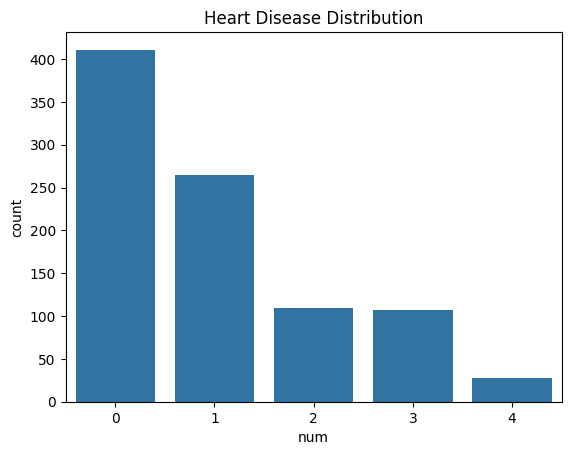

In [16]:
sns.countplot(x='num', data=df)
plt.title("Heart Disease Distribution")
plt.show()

Correlation Heatmap

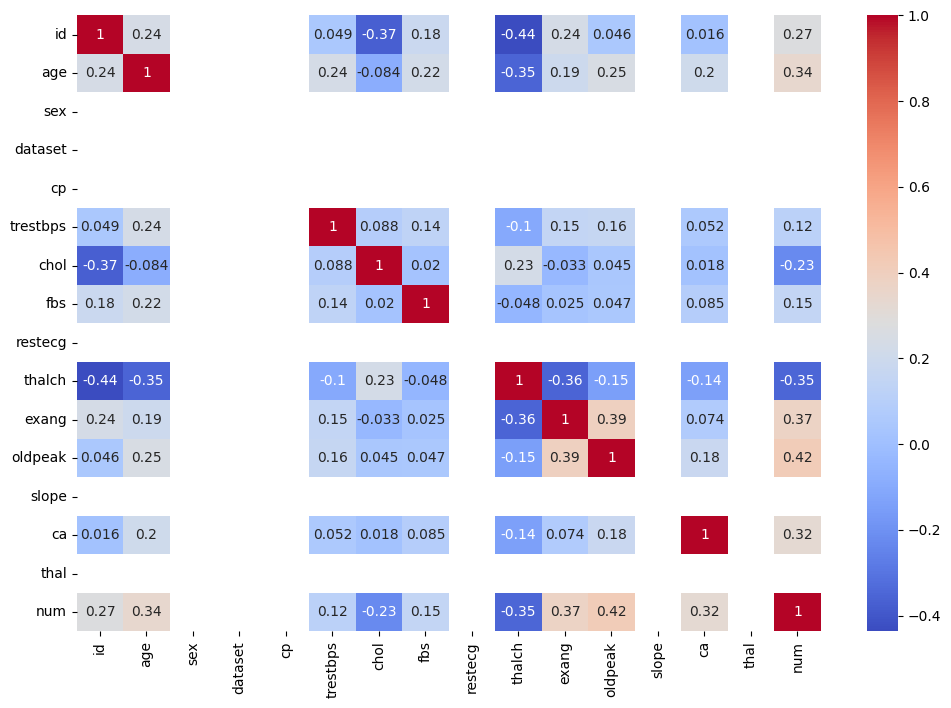

In [17]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

Age vs Target

In [19]:
df['target'] = df['num'].apply(lambda x: 1 if x > 0 else 0)

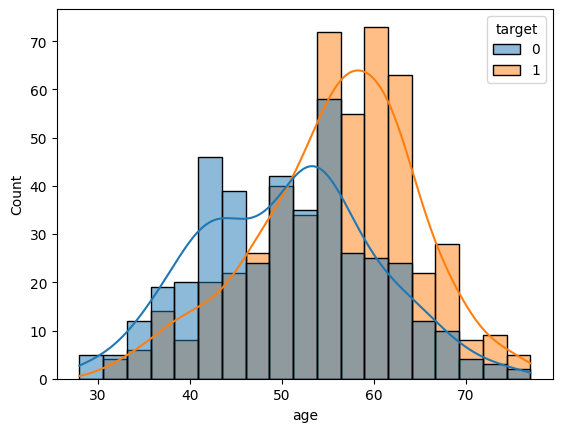

In [20]:
sns.histplot(data=df, x='age', hue='target', kde=True)
plt.show()

In [66]:
X = df.drop("target", axis=1)
y = df["target"]

In [67]:
feature_names = X.columns.tolist()

Split

In [68]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

Scaling

In [69]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


Train Model

In [72]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("model", LogisticRegression())
])

pipe.fit(X_train, y_train)

Pipeline(steps=[('imputer', SimpleImputer()), ('model', LogisticRegression())])

In [73]:
X = df.drop("target", axis=1)
y = df["target"]

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

imputer = SimpleImputer(strategy="mean")
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['sex' 'dataset' 'cp' 'restecg' 'slope' 'thal']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['sex' 'dataset' 'cp' 'restecg' 'slope' 'thal']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


LogisticRegression(max_iter=1000)

Make Predictions

In [74]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

Accuracy

In [75]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 1.0


Confusion Matrix

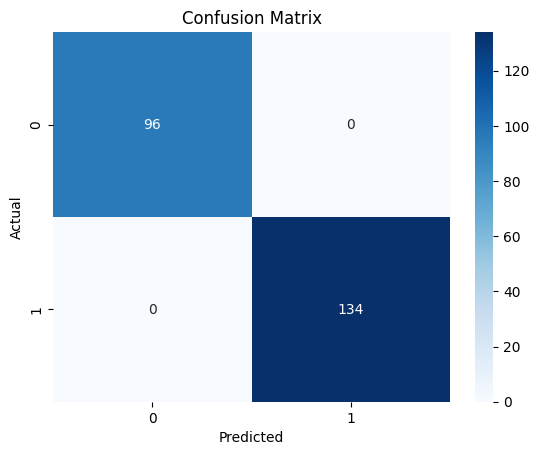

In [76]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

ROC curve

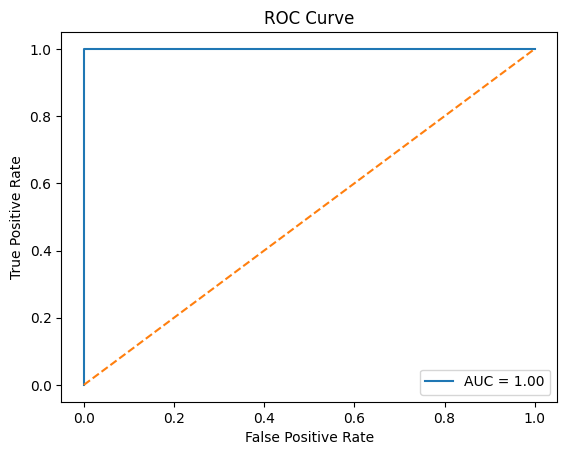

In [77]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

Feature Importance

In [84]:
feature_names = X.columns[:len(model.coef_.flatten())]

In [85]:
importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': model.coef_.flatten()
}).sort_values(by='Importance', ascending=False)

importance

,Feature,Importance
9,thalch,6.749749
6,chol,0.498612
8,restecg,0.319535
7,fbs,0.254631
4,cp,0.052120
2,sex,0.004329
0,id,0.000986
3,dataset,-0.001149
5,trestbps,-0.006963
1,age,-0.008947


Plot Feature Importance

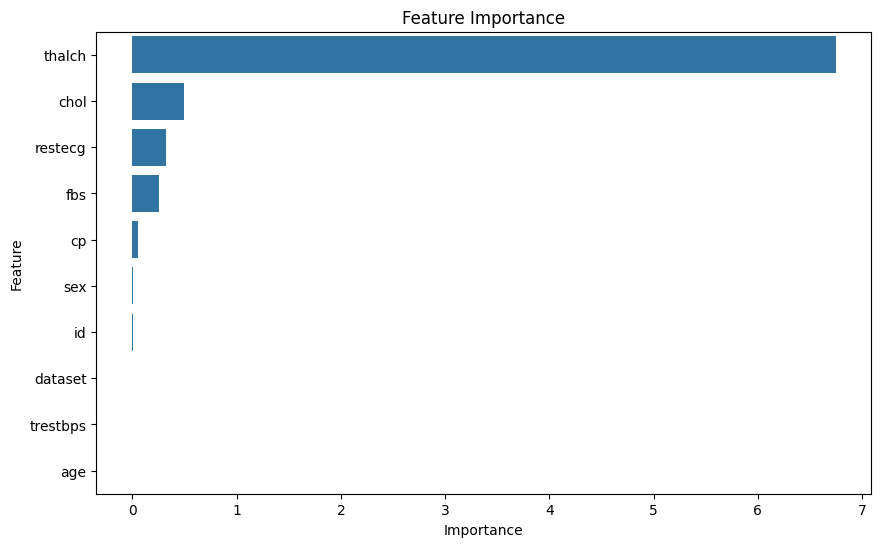

In [86]:
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=importance)
plt.title("Feature Importance")
plt.show()

Final Insights  ## Final Insights

- Logistic Regression achieved good accuracy for heart disease prediction.
- ROC curve shows how well the model distinguishes between patients with and without heart disease.
- Important features such as chest pain type, maximum heart rate, and cholesterol strongly affect prediction.
- The model can assist in early heart disease detection.